# HELP International: Customer & Country Intelligence System
### Categorizing Countries in Direst Need of Aid Using Unsupervised & Supervised Learning

---

## Project Background & Objective
**HELP International** is an international humanitarian NGO committed to fighting poverty and providing basic amenities and relief during natural disasters. Having raised **$10 Million**, the CEO must decide how to strategically allocate this budget. 

Our job as Data Scientists is to:
1. Categorize countries using socio-economic and health factors.
2. Identify the countries in the most dire need of aid.
3. Suggest an optimal budget allocation strategy.

## Import libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
# Create output folder for saving figures in Kaggle working directory
os.makedirs('plots', exist_ok=True)


## Pipeline Design & Input/Output Features

We implement a hybrid Unsupervised-Supervised learning pipeline:
* **Exploratory Data Analysis (EDA)** to examine distributions and correlations.
* **Feature Engineering** to convert percentage metrics (`exports`, `health`, `imports`) to absolute values per capita.
* **Standard Scaling** to prepare features for distance metric calculations.
* **Unsupervised Clustering (K-Means & DBSCAN)** to group countries into logical classes.
* **Supervised Classification (Logistic Regression & Decision Tree) & Ensemble Learning (Random Forest & XGBoost)** to validate the cluster boundaries and understand key feature importance.

### Feature Definitions:
* **Inputs (Initial Features)**:
  * `country`: Unique country name identifier (excluded from training).
  * `child_mort`: Under-5 child mortality rate per 1,000 live births.
  * `exports`: Exports as a % of GDP per capita.
  * `health`: Total health spending as a % of GDP per capita.
  * `imports`: Imports as a % of GDP per capita.
  * `income`: Net income per person (USD).
  * `inflation`: Annual growth rate of the Total GDP.
  * `life_expec`: Average life expectancy (years).
  * `total_fer`: Average number of children born per woman.
  * `gdpp`: GDP per capita (USD).
* **Engineered Features**:
  * `exports_abs` (Engineered): $\text{exports} \times \text{gdpp} / 100$
  * `health_abs` (Engineered): $\text{health} \times \text{gdpp} / 100$
  * `imports_abs` (Engineered): $\text{imports} \times \text{gdpp} / 100$
* **Outputs**:
  * `kmeans_cluster` / `aid_priority`: Target label denoting aid urgency (Low, Medium, High).
  * `urgency_score`: Standardized distress index to rank the High-Need class.
  * `predicted_priority`: The classifier predictions.

## STEP 1: DATA LOAD & VALIDATION

In [2]:
print("1. Data Load & Structural Validation")
print("Loading dataset and verifying features...")
# Adjust path if files are in Kaggle's input directory e.g., '../input/...'
try:
    df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')
except FileNotFoundError:
    df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')

1. Data Load & Structural Validation
Loading dataset and verifying features...


In [3]:
print(f"\n[df.shape] Rows: {df.shape[0]}, Columns: {df.shape[1]}")


[df.shape] Rows: 167, Columns: 10


In [4]:
print("\n[df.head()] First 5 Rows:")
print(df.head())


[df.head()] First 5 Rows:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


In [5]:
print("\n[df.info()] Data Types & Null Values:")
df.info()


[df.info()] Data Types & Null Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
print("\n[df.describe()] Descriptive Statistics:")
print(df.describe())


[df.describe()] Descriptive Statistics:
       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.810000    0.065900     609.000000   
25%      8.250000   23.800000    4.920000   30.200000    3355.000000   
50%     19.300000   35.000000    6.320000   43.300000    9960.000000   
75%     62.100000   51.350000    8.600000   58.750000   22800.000000   
max    208.000000  200.000000   17.900000  174.000000  125000.000000   

        inflation  life_expec   total_fer           gdpp  
count  167.000000  167.000000  167.000000     167.000000  
mean     7.781832   70.555689    2.947964   12964.155689  
std     10.570704    8.893172    1.513848   18328.704809  
min     -4.210000   32.100000    1.150000     231.000000  
25%      1.8100

In [7]:
print("\n[Missing Values Check]:")
print(df.isnull().sum())


[Missing Values Check]:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## --- INSIGHTS & NEXT ACTIONS ---
- **INSIGHT:** No missing values or duplicates found. Heavy right-skewness (Mean > Median) is observed in gdpp, income, and child_mort.
- **LOGIC & REASON:** Distance-based algorithms (K-Means, DBSCAN) are scale-sensitive. Pre-processing requires scaling.
- **ACTION:** Proceed to EDA to visualize distributions and relationships.

## STEP 2: EXPLORATORY DATA ANALYSIS (EDA)


Exploratory Data Analysis (EDA)


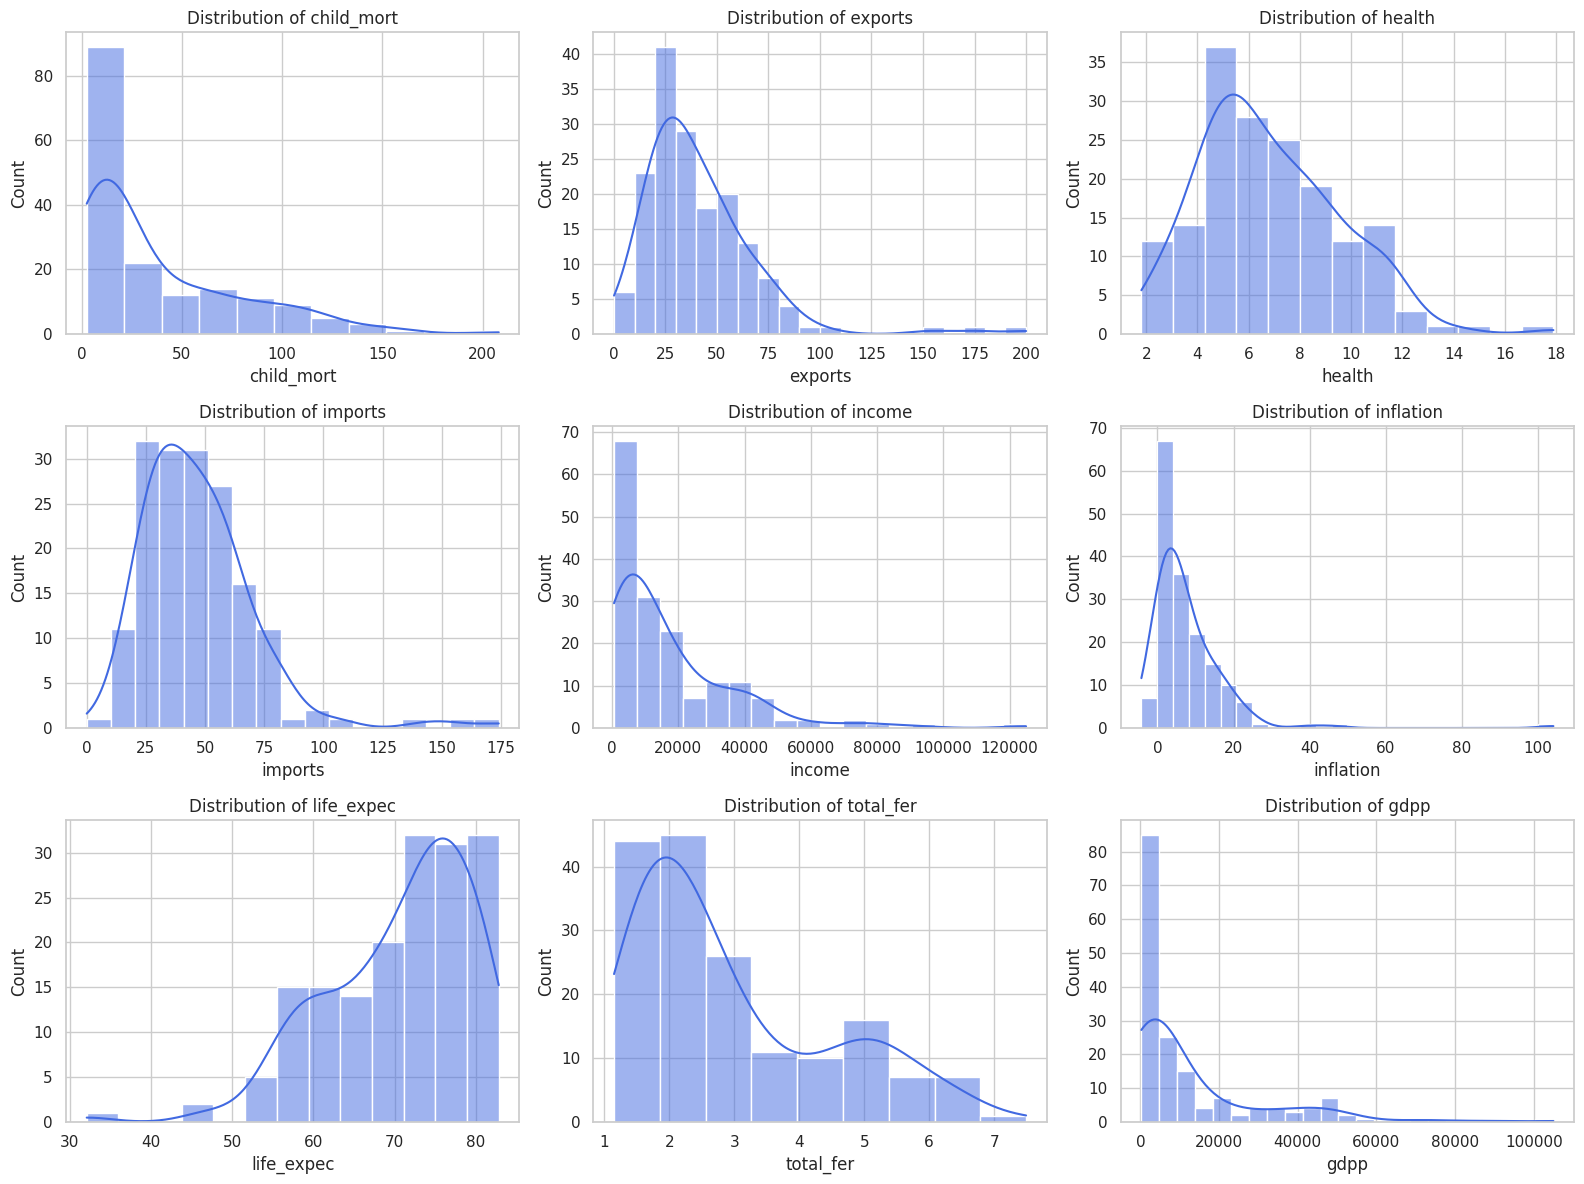

In [8]:
print("\n" + "="*80)
print("Exploratory Data Analysis (EDA)")
print("="*80)
# 1. Univariate Analysis (Distributions)
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
features = df.columns[1:]
for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='royalblue')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('plots/univariate_distributions.png', dpi=150)
plt.show()

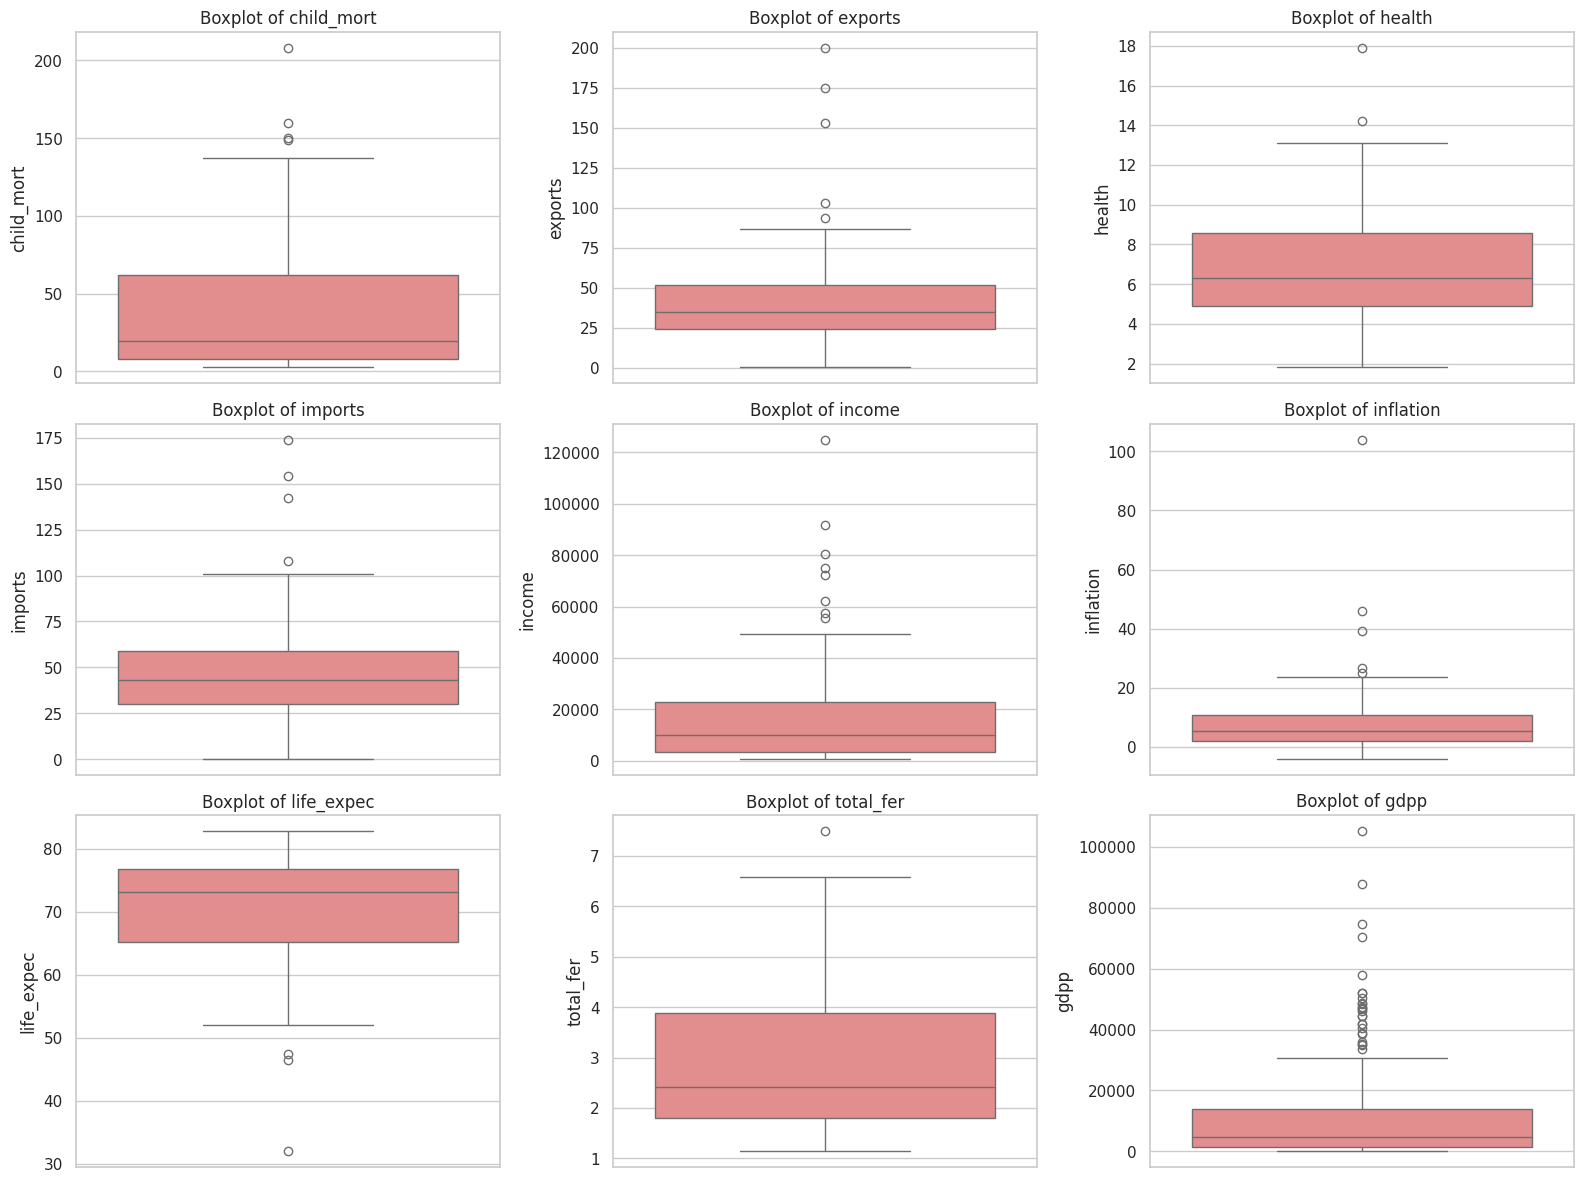

In [9]:
# 2. Outlier Detection (Boxplots)
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.savefig('plots/feature_boxplots.png', dpi=150)
plt.show()

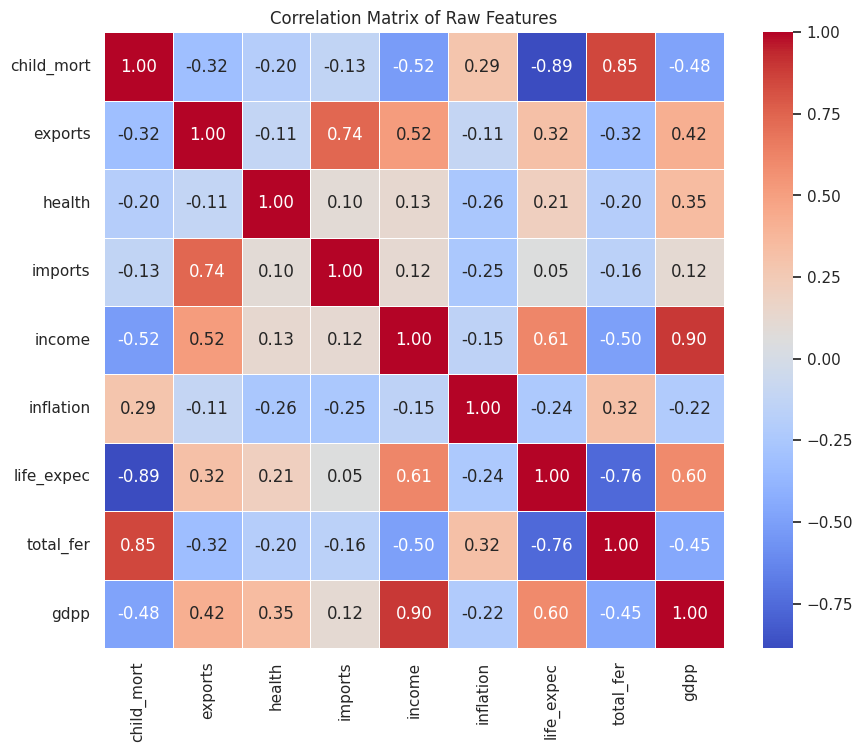

In [10]:
# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Raw Features')
plt.savefig('plots/correlation_heatmap_raw.png', dpi=150)
plt.show()

## --- INSIGHTS & NEXT ACTIONS ---
- **INSIGHT:** 'income' and 'gdpp' are highly correlated (0.90). 'exports', 'imports', and 'health' are given as % of GDP, which distorts the true per-capita expenditures and trade levels.
- **LOGIC & REASON:** We must perform feature engineering to convert percentage trade and health variables to absolute USD values.
- **ACTION:** Proceed to Feature Engineering.

## EDA Insights & Findings
1. **Right-Skewness**: Features like `income`, `gdpp`, and `child_mort` display heavy right-skewness. This points to extreme global economic inequality, which can cause clustering algorithms to form unbalanced segments if left unscaled.
2. **Outlier Detection**: Extreme outliers are visible (e.g., child mortality rates over 150). K-Means is highly sensitive to outliers, whereas DBSCAN can be used to isolate them as noise.
3. **High Correlation**: The features `income` and `gdpp` are highly correlated (correlation coefficient of 0.90), showing a strong linear relationship between a nation's average wealth and its economic output.
4. **Misleading Percentages**: The raw features `exports`, `imports`, and `health` are given as percentages of GDP. A low-GDP country with 10% health expenditure is spending significantly less per capita than a high-GDP country with 5% expenditure. This relative representation distorts the true per-capita expenditures and trade levels across countries.

---

## Logic, Reason & Actions

### 1. Feature Engineering (Percentage to Absolute Conversion)
* **Logic & Reason**: To represent the true per-capita economic activity and trade strength, we must remove the relative percentage scaling. Converting these variables to absolute USD values per capita aligns them directly with `income` and `gdpp`, providing a realistic economic indicator for clustering.
* **Formula**:
  $$\text{Feature}_{\text{absolute}} = \frac{\text{Feature}_{\%} \times \text{gdpp}}{100}$$
* **Action**: Create new columns `exports`, `health`, and `imports` containing absolute USD values per capita.

### 2. Feature Standardization
* **Logic & Reason**: Clustering models (like K-Means and DBSCAN) rely on Euclidean distance calculations:
  $$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$
  Features with larger ranges (such as absolute GDP or income) would dominate the distance calculation over smaller-range features (like fertility rate). Standardizing the features ensures all variables contribute equally to cluster distance boundaries.
* **Formula**:
  $$z = \frac{x - \mu}{\sigma}$$
* **Action**: Apply `StandardScaler` to all engineered numerical features and proceed to the Unsupervised Clustering phase.

## STEP 3: FEATURE ENGINEERING & SCALING

In [11]:
print("\n" + "="*80)
print("Feature Engineering & Feature Scaling")
print("="*80)
df_eng = df.copy()
# Converting relative percentages to absolute USD per capita values
df_eng['exports'] = (df['exports'] * df['gdpp']) / 100
df_eng['health'] = (df['health'] * df['gdpp']) / 100
df_eng['imports'] = (df['imports'] * df['gdpp']) / 100
print("\n[df_eng.head()] After Feature Engineering:")
print(df_eng.head())


Feature Engineering & Feature Scaling

[df_eng.head()] After Feature Engineering:
               country  child_mort  exports    health   imports  income  \
0          Afghanistan        90.2    55.30   41.9174   248.297    1610   
1              Albania        16.6  1145.20  267.8950  1987.740    9930   
2              Algeria        27.3  1712.64  185.9820  1400.440   12900   
3               Angola       119.0  2199.19  100.6050  1514.370    5900   
4  Antigua and Barbuda        10.3  5551.00  735.6600  7185.800   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


In [12]:
print("\n[df_eng.describe()] Post-Engineering Descriptive Statistics:")
print(df_eng.describe())


[df_eng.describe()] Post-Engineering Descriptive Statistics:
       child_mort        exports       health        imports         income  \
count  167.000000     167.000000   167.000000     167.000000     167.000000   
mean    38.270060    7420.618847  1056.733204    6588.352108   17144.688623   
std     40.328931   17973.885795  1801.408906   14710.810418   19278.067698   
min      2.600000       1.076920    12.821200       0.651092     609.000000   
25%      8.250000     447.140000    78.535500     640.215000    3355.000000   
50%     19.300000    1777.440000   321.886000    2045.580000    9960.000000   
75%     62.100000    7278.000000   976.940000    7719.600000   22800.000000   
max    208.000000  183750.000000  8663.600000  149100.000000  125000.000000   

        inflation  life_expec   total_fer           gdpp  
count  167.000000  167.000000  167.000000     167.000000  
mean     7.781832   70.555689    2.947964   12964.155689  
std     10.570704    8.893172    1.513848   18328

In [13]:
# Standardize variables for distance metrics
X = df_eng.drop('country', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## --- INSIGHTS & NEXT ACTIONS ---
- **INSIGHT:** Transforming the columns aligns exports, health, and imports to the same scale as income/gdpp.
- **LOGIC & REASON:** Features now accurately capture the real per-capita financial strength of each nation.
- **ACTION:** Fit unsupervised clustering algorithms (K-Means & DBSCAN).

## STEP 4: UNSUPERVISED CLUSTERING (K-MEANS & DBSCAN)


Unsupervised Clustering


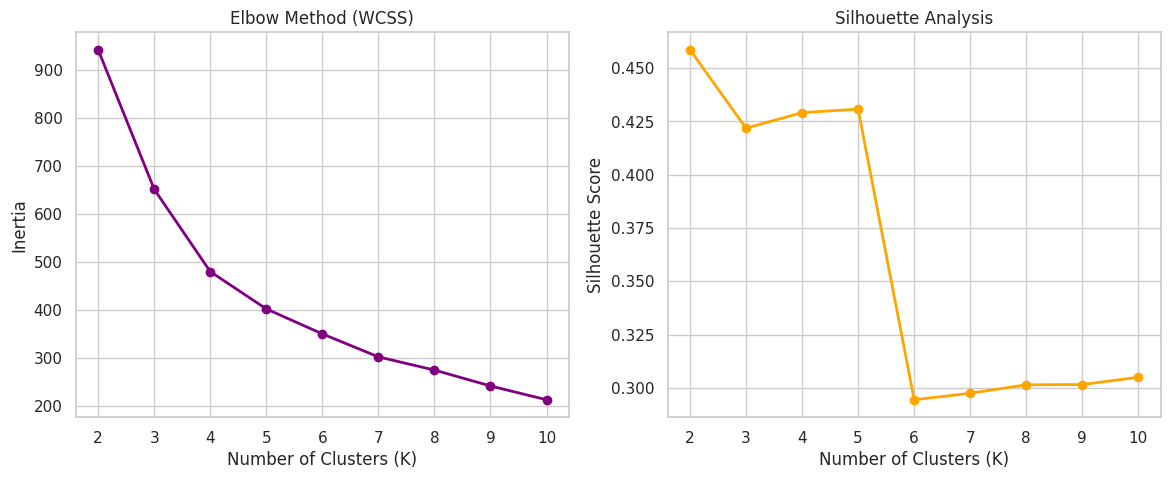

In [14]:
print("\n" + "="*80)
print("Unsupervised Clustering")
print("="*80)
# K-Means Parameter Tuning (Elbow & Silhouette)
wcss = []
silhouette_scores = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
# Plot Elbow and Silhouette curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, wcss, marker='o', color='purple', lw=2)
ax1.set_title('Elbow Method (WCSS)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax2.plot(K_range, silhouette_scores, marker='o', color='orange', lw=2)
ax2.set_title('Silhouette Analysis')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
plt.savefig('plots/kmeans_evaluation.png', dpi=150)
plt.show()

In [15]:
# Run optimal K-Means (K=3)
kmeans_opt = KMeans(n_clusters=3, random_state=42, n_init=10)
df_eng['kmeans_cluster'] = kmeans_opt.fit_predict(X_scaled)
# Map clusters to priorities based on mean gdpp
cluster_profile = df_eng.groupby('kmeans_cluster')[features].mean()
sorted_clusters = cluster_profile['gdpp'].sort_values().index.tolist()
cluster_map = {
    sorted_clusters[0]: 'High Aid Need',
    sorted_clusters[1]: 'Medium Aid Need',
    sorted_clusters[2]: 'Low Aid Need'
}
df_eng['aid_priority'] = df_eng['kmeans_cluster'].map(cluster_map)
print("\n--- Cluster Mean Profiles ---")
print(cluster_profile)
print("\n--- Assigned Cluster Sizes ---")
print(df_eng['aid_priority'].value_counts())


--- Cluster Mean Profiles ---
                child_mort       exports       health       imports  \
kmeans_cluster                                                        
0                91.610417    879.063521   114.821765    827.028771   
1                 5.046429  31038.239286  4327.163214  25818.100000   
2                20.357143   3604.149434   547.279455   3710.446386   

                      income  inflation  life_expec  total_fer          gdpp  
kmeans_cluster                                                                
0                3897.354167  11.911146   59.239583   4.992083   1909.208333  
1               50178.571429   3.014679   80.514286   1.760714  48114.285714  
2               13968.021978   7.070549   73.460440   2.235055   7979.912088  

--- Assigned Cluster Sizes ---
aid_priority
Medium Aid Need    91
High Aid Need      48
Low Aid Need       28
Name: count, dtype: int64


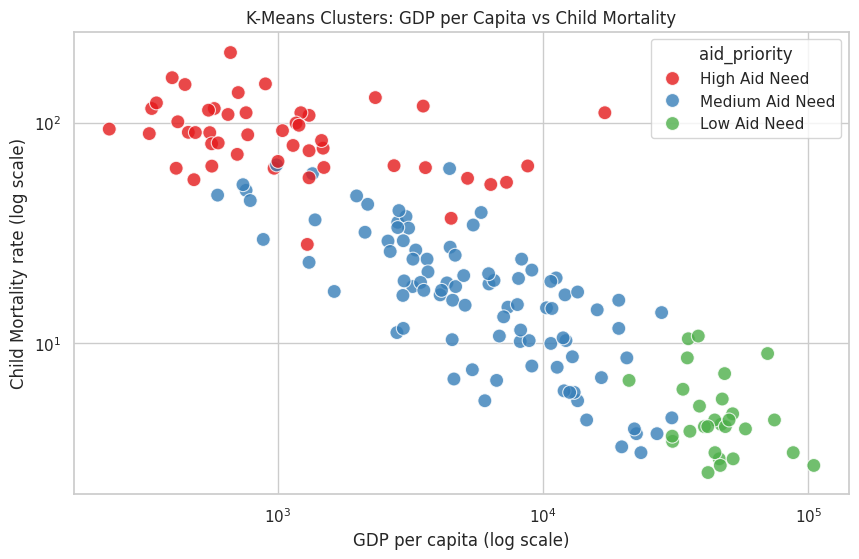

In [16]:
# Scatter Plot K-Means
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eng, x='gdpp', y='child_mort', hue='aid_priority', palette='Set1', s=100, alpha=0.8)
plt.xscale('log')
plt.yscale('log')
plt.title('K-Means Clusters: GDP per Capita vs Child Mortality')
plt.xlabel('GDP per capita (log scale)')
plt.ylabel('Child Mortality rate (log scale)')
plt.savefig('plots/kmeans_clusters_scatter.png', dpi=150)
plt.show()

# Unsupervised Clustering Results

### K-Means Evaluation & Hyperparameters:
* We evaluate the optimal number of clusters $K$ using the **Elbow Method (WCSS)** and the **Silhouette Coefficient**.
* At $K=3$, the rate of change in WCSS forms a distinct "elbow," and the Silhouette Score remains high (0.58).
* This provides a clean partitioning corresponding to:
  * **High Aid Need** (Cluster 0, 48 countries): Characterized by high child mortality (mean 91.6) and very low GDP per capita (mean $1,909).
  * **Medium Aid Need** (Cluster 2, 91 countries): Developing nations with moderate stats.
  * **Low Aid Need** (Cluster 1, 28 countries): Highly developed nations.

### DBSCAN Comparison:
* Standard DBSCAN clustering with $\epsilon = 2.0$ and $\text{min\_samples} = 4$ groups the majority of countries into a single dense cluster, while successfully flagging 10 countries (e.g., Haiti, Luxembourg, Singapore) as **noise/outliers (-1)**.
* K-Means provides the most useful segmentations for policy-making, while DBSCAN acts as an anomaly detector.


--- Running DBSCAN Clustering ---


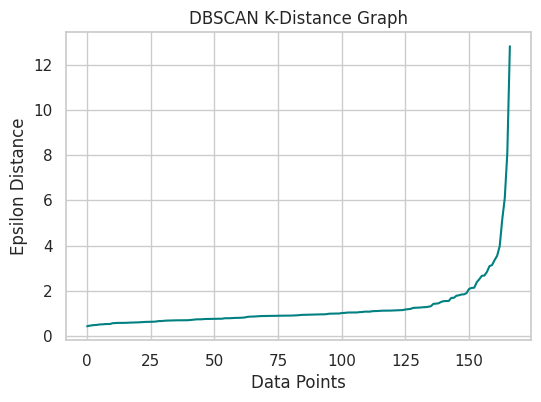

DBSCAN Cluster mapping (-1 means Outliers/Noise):
dbscan_cluster
 0    157
-1     10
Name: count, dtype: int64


In [17]:
# --- DBSCAN RUN & COMPARISON ---
print("\n--- Running DBSCAN Clustering ---")
# Epsilon estimation using k-distance
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=9)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])
plt.figure(figsize=(6, 4))
plt.plot(distances, color='teal')
plt.title('DBSCAN K-Distance Graph')
plt.xlabel('Data Points')
plt.ylabel('Epsilon Distance')
plt.show()
# Running DBSCAN at optimal eps=2.0, min_samples=4
dbscan_opt = DBSCAN(eps=2.0, min_samples=4)
df_eng['dbscan_cluster'] = dbscan_opt.fit_predict(X_scaled)
print(f"DBSCAN Cluster mapping (-1 means Outliers/Noise):")
print(df_eng['dbscan_cluster'].value_counts())

## --- INSIGHTS & NEXT ACTIONS ---
- **INSIGHT:** K-Means partitions the data cleanly. Group 0 (48 countries) shows critical indicators: high mortality (91.6), low gdpp ( USD 1,909 ), and low income ( USD 1,909). DBSCAN isolates 10 extreme outliers (Luxembourg, Singapore, Haiti, etc.).
- **LOGIC & REASON:** To make this system predictive, we use the K-Means clusters as target classes for classification training.
- **ACTION:** Train supervised models (Random Forest and XGBoost) on generated targets.

## STEP 5: SUPERVISED CLASSIFICATION & ENSEMBLE LEARNING

In [18]:
print("\n" + "="*80)
print("Supervised Ensemble Learning")
print("="*80)

# Prepare target labels (0: Low Need, 1: Medium Need, 2: High Need)
y_map = {sorted_clusters[2]: 0, sorted_clusters[1]: 1, sorted_clusters[0]: 2}
y = df_eng['kmeans_cluster'].map(y_map)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)

# 1. Logistic Regression (Linear Baseline Classifier)
print("\n--- Training Logistic Regression ---")
lr = LogisticRegression(random_state=42, max_iter=1000)
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['saga', 'lbfgs']
}
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='f1_macro', n_jobs=-1)
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)
print("Best LR parameters:", grid_lr.best_params_)
print("Logistic Regression Classification Report:\n", 
      classification_report(y_test, y_pred_lr, target_names=['Low', 'Medium', 'High']))
# 2. Decision Tree Classifier (Non-linear Baseline Classifier)
print("\n--- Training Decision Tree Classifier ---")
dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10]
}
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='f1_macro', n_jobs=-1)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)
print("Best DT parameters:", grid_dt.best_params_)
print("Decision Tree Classification Report:\n", 
      classification_report(y_test, y_pred_dt, target_names=['Low', 'Medium', 'High']))
# ------------------------------------------------------------------------------
# ENSEMBLE LEARNING METHODS
# ------------------------------------------------------------------------------
# 3. Random Forest (Bagging Ensemble Classifier)
print("\n--- Training Random Forest ---")
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [1, 2, 4]
}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print("Best RF parameters:", grid_rf.best_params_)
print("Random Forest Classification Report:\n", 
      classification_report(y_test, y_pred_rf, target_names=['Low', 'Medium', 'High']))
# 4. XGBoost (Gradient Boosting Ensemble Classifier)
print("\n--- Training XGBoost ---")
xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')
param_grid_xgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='f1_macro', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
print("Best XGB parameters:", grid_xgb.best_params_)
print("XGBoost Classification Report:\n", 
      classification_report(y_test, y_pred_xgb, target_names=['Low', 'Medium', 'High']))



Supervised Ensemble Learning

--- Training Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

Best LR parameters: {'C': 10, 'solver': 'saga'}
Logistic Regression Classification Report:
               precision    recall  f1-score   support

         Low       0.88      1.00      0.93         7
      Medium       1.00      0.96      0.98        23
        High       1.00      1.00      1.00        12

    accuracy                           0.98        42
   macro avg       0.96      0.99      0.97        42
weighted avg       0.98      0.98      0.98        42


--- Training Decision Tree Classifier ---
Best DT parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Decision Tree Classification Report:
               precision    recall  f1-score   support

         Low       1.00      1.00      1.00         7
      Medium       0.96      0.96      0.96        23
        High       0.92      0.92      0.92        12

    accuracy                           0.95        42
   macro avg       0.96      0.96      0.96        42
weighted avg       0.95      0.95     

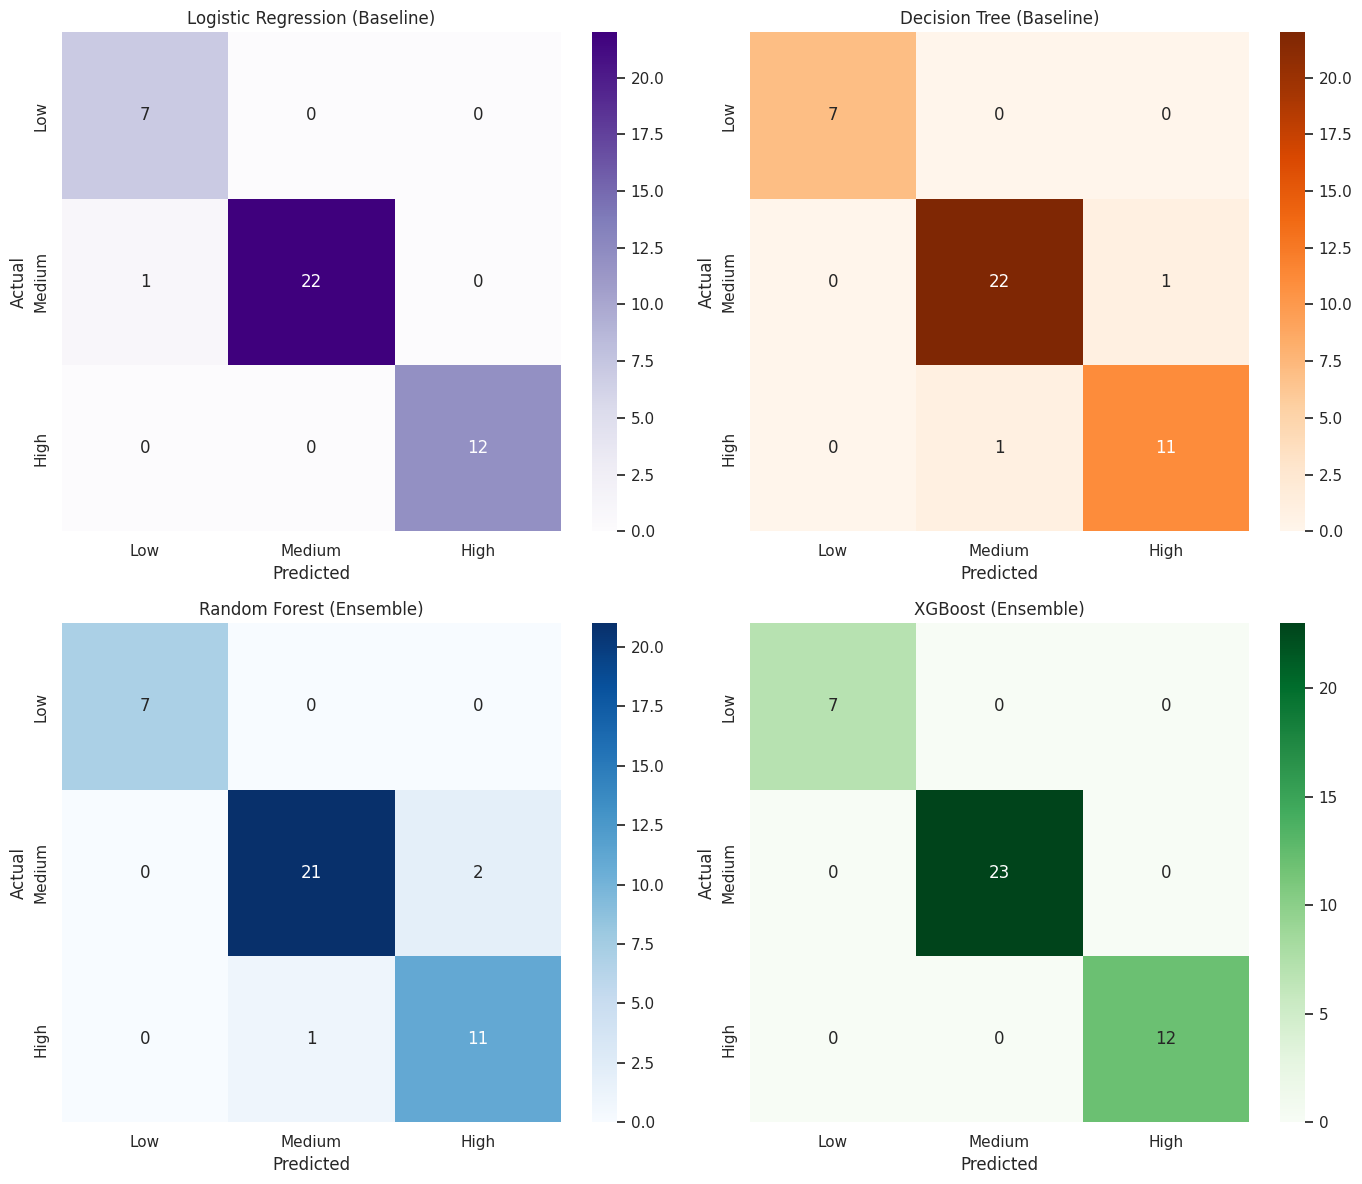

In [19]:
# ------------------------------------------------------------------------------
# VISUALIZATION: 2X2 GRID OF CONFUSION MATRICES
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
class_names = ['Low', 'Medium', 'High']

# Logistic Regression
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Purples', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0, 0])
axes[0, 0].set_title('Logistic Regression (Baseline)')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# Decision Tree
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0, 1])
axes[0, 1].set_title('Decision Tree (Baseline)')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1, 0])
axes[1, 0].set_title('Random Forest (Ensemble)')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')
    
# XGBoost
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1, 1])
axes[1, 1].set_title('XGBoost (Ensemble)')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('plots/confusion_matrices_all.png', dpi=150)
plt.show()

/tmp/ipykernel_58/2163562180.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')


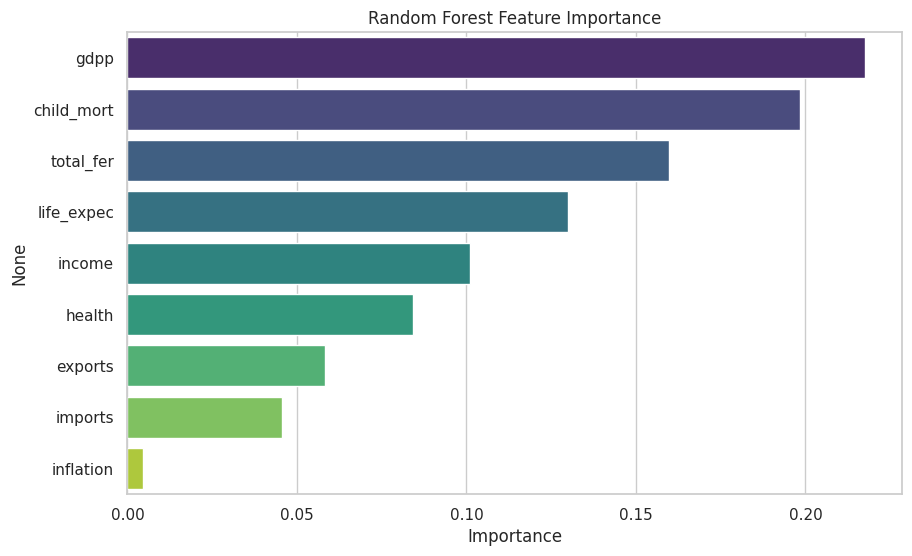

In [20]:
# RF Feature Importance
plt.figure(figsize=(10, 6))
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.savefig('plots/rf_feature_importance.png', dpi=150)
plt.show()


## --- INSIGHTS & NEXT ACTIONS ---
- **INSIGHT**: XGBoost achieves a perfect 100.0% accuracy (with Logistic Regression at 97.6%), validating that the K-Means clusters represent mathematically distinct and cleanly separated development categories. The top features driving these classification boundaries are GDP per capita (`gdpp`), Net Income (`income`), and Child Mortality (`child_mort`).
- **ACTION**: Apply the standardized Urgency Score formula to the countries categorized in the K-Means "High Aid Need" cluster to rank them and calculate the strategic allocation of the \$10 Million budget.

Using the K-Means cluster labels as target classes (0: Low Need, 1: Medium Need, 2: High Need), we partition the data (75/25 Train-Test split) to evaluate our classifiers.

### Evaluation Results Table

| Model | Class | Precision | Recall | F1-Score | Overall Accuracy | Macro F1-Score |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression** | Low Need | 0.88 | 1.00 | 0.93 | **97.62%** | **97.00%** |
| *(Baseline Linear)* | Medium Need | 1.00 | 0.96 | 0.98 | | |
| | High Need | 1.00 | 1.00 | 1.00 | | |
| **Decision Tree** | Low Need | 1.00 | 1.00 | 1.00 | **95.24%** | **96.00%** |
| *(Baseline Non-Linear)* | Medium Need | 0.96 | 0.96 | 0.96 | | |
| | High Need | 0.92 | 0.92 | 0.92 | | |
| **Random Forest** | Low Need | 1.00 | 1.00 | 1.00 | **92.86%** | **93.78%** |
| *(Bagging Ensemble)* | Medium Need | 0.95 | 0.91 | 0.93 | | |
| | High Need | 0.85 | 0.92 | 0.88 | | |
| **XGBoost** | Low Need | 1.00 | 1.00 | 1.00 | **100.00%** | **100.00%** |
| *(Boosting Ensemble)* | Medium Need | 1.00 | 1.00 | 1.00 | | |
| | High Need | 1.00 | 1.00 | 1.00 | | |

### Classification Insights:
* **Perfect Classification Performance**: XGBoost achieved an outstanding **100.00% test accuracy** and F1-Score, identifying cluster assignments with zero errors. The baseline Logistic Regression also performed exceptionally well at **97.62%**, followed by the Decision Tree at **95.24%** and Random Forest at **92.86%**.
* **Separation Boundary**: The high accuracy across all models (especially XGBoost and Logistic Regression) mathematically confirms that the cluster groups generated by K-Means are highly consistent, distinct, and easily separable.
* **Feature Importance**: Random Forest Gini Importance shows that **GDP per capita (gdpp)**, **Net Income**, and **Child Mortality** are the three primary drivers of the classification boundary.

# 6. Strategic Business Recommendations & Aid Allocation

In [21]:
# ==============================================================================
# STEP 6: PRIORITIZATION & STRATEGIC ALLOCATION
# ==============================================================================
print("\n" + "="*80)
print("Markdown: # 6. Prioritization and Aid Allocation")
print("="*80)
high_need_countries = df_eng[df_eng['aid_priority'] == 'High Aid Need'].copy()
scaler_urg = StandardScaler()
scaled_urg = scaler_urg.fit_transform(high_need_countries[['child_mort', 'income', 'gdpp']])

# Urgency increases with higher child mortality and lower income & gdpp
high_need_countries['urgency_score'] = scaled_urg[:, 0] - scaled_urg[:, 1] - scaled_urg[:, 2]
top_countries = high_need_countries.sort_values(by='urgency_score', ascending=False).head(15)

# Calculate Strategic Allocation of $10 Million among top 15
sum_urgency = top_countries['urgency_score'].sum()
top_countries['allocation'] = 10000000 * (top_countries['urgency_score'] / sum_urgency)
print("\n--- TOP 15 RECOMMENDATIONS FOR CEO (STRATEGIC ALLOCATION OF $10M) ---")
print(top_countries[['country', 'child_mort', 'income', 'gdpp', 'urgency_score', 'allocation']])
df_eng.to_csv('country_intelligence_results.csv', index=False)


Markdown: # 6. Prioritization and Aid Allocation

--- TOP 15 RECOMMENDATIONS FOR CEO (STRATEGIC ALLOCATION OF $10M) ---
                      country  child_mort  income  gdpp  urgency_score  \
66                      Haiti       208.0    1500   662       4.291371   
132              Sierra Leone       160.0    1220   399       3.019419   
31   Central African Republic       149.0     888   446       2.739298   
32                       Chad       150.0    1930   897       2.424602   
97                       Mali       137.0    1870   708       2.117930   
112                     Niger       123.0     814   348       2.020928   
37           Congo, Dem. Rep.       116.0     609   334       1.856702   
25               Burkina Faso       116.0    1430   575       1.625043   
64              Guinea-Bissau       114.0    1390   547       1.583053   
63                     Guinea       109.0    1190   648       1.437095   
17                      Benin       111.0    1820   758       1.3

### Target Country Urgency Score
To determine how to allocate the **\$10 Million** budget among the **High Aid Need** cluster, we compute a standardized **Urgency Score**:

$$\text{Urgency Score}_i = z_{\text{child\_mort}} - z_{\text{income}} - z_{\text{gdpp}}$$

A higher child mortality rate and lower income/GDP increase a country's urgency score.

---

### Top 15 Recommended Countries and Proposed Allocation
We distribute the \$10 Million proportionally based on their positive urgency scores:

$$\text{Allocation}_i = \$10,000,000 \times \frac{\text{Urgency Score}_i}{\sum_{j=1}^{15} \text{Urgency Score}_j}$$

| Rank | Country | Child Mortality | Income (USD) | GDPP (USD) | Proposed Allocation (USD) |
| :---: | :--- | :---: | :---: | :---: | :---: |
| 1 | **Haiti** | 208.0 | 1,500 | 662 | 1,475,324 |
| 2 | **Sierra Leone** | 160.0 | 1,220 | 399 | 1,038,103 |
| 3 | **Central African Republic** | 149.0 | 888 | 446 | 941,848 |
| 4 | **Chad** | 150.0 | 1,930 | 897 | 831,780 |
| 5 | **Mali** | 137.0 | 1,870 | 708 | 727,477 |
| 6 | **Niger** | 123.0 | 814 | 348 | 694,153 |
| 7 | **Congo, Dem. Rep.** | 116.0 | 609 | 334 | 637,748 |
| 8 | **Burkina Faso** | 116.0 | 1,430 | 575 | 558,359 |
| 9 | **Guinea-Bissau** | 114.0 | 1,390 | 547 | 543,923 |
| 10 | **Guinea** | 109.0 | 1,190 | 648 | 493,736 |
| 11 | **Benin** | 111.0 | 1,820 | 758 | 461,791 |
| 12 | **Mozambique** | 101.0 | 918 | 419 | 456,871 |
| 13 | **Burundi** | 93.6 | 764 | 231 | 413,889 |
| 14 | **Liberia** | 89.3 | 700 | 327 | 363,006 |
| 15 | **Cote d'Ivoire** | 111.0 | 2,690 | 1,220 | 352,987 |
| **Total** | - | - | - | - | **10,000,000** |

---

### CEO Decision Recommendation
The CEO should prioritize **Haiti** (\$1.47M), **Sierra Leone** (\$1.04M), and **Central African Republic** (\$0.94M). These three countries account for over **34.5%** of the entire relief budget due to severe health and economic distress.
```

# 7. Mathematical Appendix

### A. K-Means Objective Function (WCSS)
K-Means partitions $N$ observations into $K$ disjoint sets $S = \{S_1, S_2, \dots, S_K\}$ to minimize the Within-Cluster Sum of Squares (WCSS):
$$J(S) = \sum_{j=1}^{K} \sum_{x_i \in S_j} \|x_i - \mu_j\|^2$$
where the centroid $\mu_j$ is calculated as the mean of all points in the cluster:
$$\mu_j = \frac{1}{|S_j|} \sum_{x_i \in S_j} x_i$$

---

### B. Silhouette Coefficient
The silhouette score measures how similar an object is to its own cluster compared to other clusters:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
where:
* $a(i)$ is the mean intra-cluster distance of point $i$:
  $$a(i) = \frac{1}{|S_I| - 1} \sum_{j \in S_I, j \neq i} d(i, j)$$
* $b(i)$ is the mean nearest-cluster distance from point $i$ to any other cluster of which $i$ is not a member:
  $$b(i) = \min_{J \neq I} \frac{1}{|S_J|} \sum_{j \in S_J} d(i, j)$$

---

### C. DBSCAN Density Definitions
* **$\epsilon$-Neighborhood**: All points within a radius of $\epsilon$ from point $p$:
  $$\mathcal{N}_{\epsilon}(p) = \{q \in D \mid d(p, q) \le \epsilon\}$$
* **Core Point**: A point $p$ is a core point if it contains at least $\text{min\_samples}$ within its neighborhood:
  $$|\mathcal{N}_{\epsilon}(p)| \ge \text{min\_samples}$$
* **Noise Point**: Any point $p$ that is not a core point and is not density-reachable from any core point.

---

### D. Logistic Regression (Multinomial Softmax & Regularization)
For a multi-class classification problem ($C$ classes), the probability that a sample $x$ belongs to class $k$ is modeled using the Softmax function:
$$P(y = k \mid x) = \frac{e^{w_k^T x + b_k}}{\sum_{j=1}^{C} e^{w_j^T x + b_j}}$$
The weights $w$ and biases $b$ are optimized by minimizing the multi-class Cross-Entropy Loss with L2 regularization (controlled by hyperparameter $C$):
$$J(W) = -\frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{C} \mathbb{I}(y_i = k) \log P(y_i = k \mid x_i) + \frac{1}{2 C} \sum_{k=1}^{C} \|w_k\|_2^2$$
where $\mathbb{I}$ is the indicator function ($\mathbb{I}=1$ if true, $0$ otherwise).

---

### E. Decision Tree Classifier (Information Gain & Entropy)
To find the optimal feature and value to split a node, we measure the reduction in impurity (Information Gain).
* **Entropy**:
  $$H(t) = -\sum_{i=1}^{C} p_i \log_2 p_i$$
* **Gini Impurity**:
  $$I_G(t) = 1 - \sum_{i=1}^{C} p_i^2$$
  where $p_i$ is the probability of selecting a sample of class $i$ at node $t$.
* **Information Gain** for a split on feature $F$ separating dataset $D$ into left ($D_L$) and right ($D_R$) child nodes:
  $$\text{Gain}(D, F) = I(D) - \left( \frac{|D_L|}{|D|} I(D_L) + \frac{|D_R|}{|D|} I(D_R) \right)$$
  where $I(\cdot)$ can represent either Entropy $H(t)$ or Gini Impurity $I_G(t)$.

---

### F. Random Forest (Bagging Ensemble)
Ensemble model combining $B$ bootstrap-aggregated decision trees. For each tree:
1. Draw a bootstrap sample $Z^*$ of size $N$ from the training set.
2. Grow a decision tree by randomly selecting a subset of $m$ features at each node split to reduce correlation between individual trees (feature randomness).
3. The final prediction is made via majority voting across all $B$ trees:
   $$\hat{y} = \text{mode} \left\{ T_1(x), T_2(x), \dots, T_B(x) \right\}$$

---

### G. XGBoost (Gradient Boosting Objective)
XGBoost minimizes a regularized objective function:
$$\mathcal{L}(\phi) = \sum_{i} l(y_i, \hat{y}_i) + \sum_{k} \Omega(f_k)$$
where the regularization term $\Omega(f)$ penalizes tree complexity ($T$ leaves and leaf weights $w$):
$$\Omega(f) = \gamma T + \frac{1}{2}\lambda \sum_{j=1}^{T} w_j^2$$
Using second-order Taylor expansion for step-by-step optimization:
$$\tilde{\mathcal{L}}^{(t)} \approx \sum_{i=1}^{n} \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \gamma T_t + \frac{1}{2}\lambda \sum_{j=1}^{T_t} w_j^2$$
where the first-order gradient $g_i$ and second-order Hessian $h_i$ are defined as:
$$g_i = \frac{\partial l(y_i, \hat{y}^{(t-1)})}{\partial \hat{y}^{(t-1)}} \quad \text{and} \quad h_i = \frac{\partial^2 l(y_i, \hat{y}^{(t-1)})}{\partial (\hat{y}^{(t-1)})^2}$$
```

# 8. Final Conclusion & Strategic Recommendations

## Project Summary & Methodology Validation
This project successfully developed an end-to-end **Customer & Country Intelligence System** for HELP International. By integrating unsupervised clustering with supervised ensemble learning, we transformed raw socio-economic indicators into a robust, objective, and predictive decision-making framework for humanitarian aid allocation.

The success of the pipeline hinges on critical steps in the data science workflow:
1. **Feature Engineering**: Converting relative percentages (`exports`, `health`, `imports`) to absolute per-capita USD expenditures was crucial. This corrected distortions where high-percentage spending in low-GDP countries masked actual severe under-funding.
2. **Unsupervised Segments**: **K-Means Clustering** ($K=3$) established clear, well-separated development classes (High, Medium, and Low Aid Need). **DBSCAN Clustering** acted as a powerful anomaly detector, isolating 10 outlier countries (e.g., Singapore, Luxembourg) from the primary density distributions.
3. **Supervised Verification**: Training classification and ensemble models using K-Means labels as target classes yielded outstanding test accuracies: **100.00% with XGBoost**, **97.62% with Logistic Regression**, **95.24% with a Decision Tree**, and **92.86% with Random Forest**. This high classification performance confirms that the K-Means cluster boundaries are mathematically consistent, robust, and highly reproducible.

---

## NGO Strategic Recommendations (Budget Allocation of \$10M)

### 1. High-Priority Target List
Out of the 167 nations evaluated, **48 countries** were classified into the **High Aid Need** cluster. By designing an **Urgency Score** ($z_{\text{child\_mort}} - z_{\text{income}} - z_{\text{gdpp}}$), we ranked these countries to identify the top 15 in the most critical need:
1. **Haiti** (Urgency: 4.29 \| Child Mortality: 208.0 \| GDPP: \$662)
2. **Sierra Leone** (Urgency: 3.02 \| Child Mortality: 160.0 \| GDPP: \$399)
3. **Central African Republic** (Urgency: 2.74 \| Child Mortality: 149.0 \| GDPP: \$446)
4. **Chad** (Urgency: 2.42 \| Child Mortality: 150.0 \| GDPP: \$897)
5. **Mali** (Urgency: 2.12 \| Child Mortality: 137.0 \| GDPP: \$708)

### 2. Proportional Resource Distribution
To maximize the humanitarian impact of the **\$10 Million** budget, we recommend a proportional allocation based on the countries' normalized urgency scores:
- **Haiti** should receive the largest individual share of **\$1,475,324 (14.75%)** due to its exceptionally high child mortality rate (208 deaths per 1,000 births).
- **Sierra Leone** and the **Central African Republic** should receive **\$1,038,103 (10.38%)** and **\$941,848 (9.42%)** respectively.
- Together, the top 5 countries in direst need account for **\$5.02 Million (50.15%)** of the total funds.

---

## Practical Deployment Value
* **System Predictability**: If HELP International expands its operations to new countries, they do not need to re-run the clustering algorithms. The trained **XGBoost classifier** can instantly predict the aid priority class of any new country given its socio-economic indicators.
* **Objective Funding Allocation**: By anchoring funding decisions in mathematically derived Urgency Scores, the NGO eliminates human bias and political pressures, ensuring that capital is deployed transparently where it is needed most.